# The Thresholds

## Imports

In [5]:
%pip install pandas seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [7]:
df = pd.read_csv('./data/creditcard.csv')
df.tail()
#print(f"Total missing values: {df.isnull().sum().sum()}")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## Target Distribution


Percentage:
Class
0    28431500
1       49200
Name: count, dtype: int64


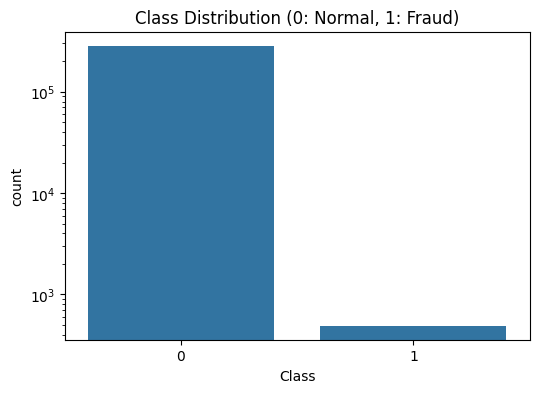

In [8]:
# Check target distribution
print("\nPercentage:")
print(df['Class'].value_counts() * 100)

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Using log scale because fraud is extremely rare
plt.show()

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


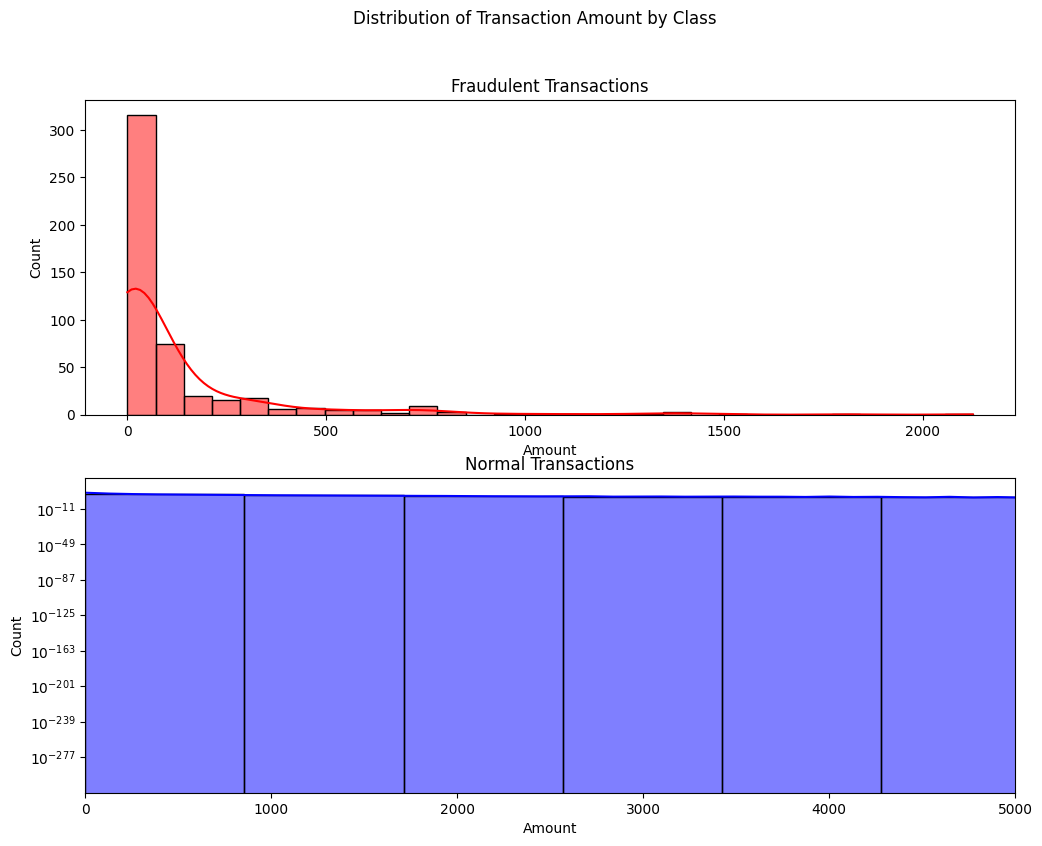

In [9]:
print(df.groupby('Class')['Amount'].describe())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
fig.suptitle('Distribution of Transaction Amount by Class')

sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, ax=ax1, color='red', kde=True)
ax1.set_title('Fraudulent Transactions')

sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, ax=ax2, color='blue', kde=True)
ax2.set_title('Normal Transactions')

plt.xlim((0, 5000)) # Most transactions are under 5000
plt.yscale('log')
plt.show()

## Correlations

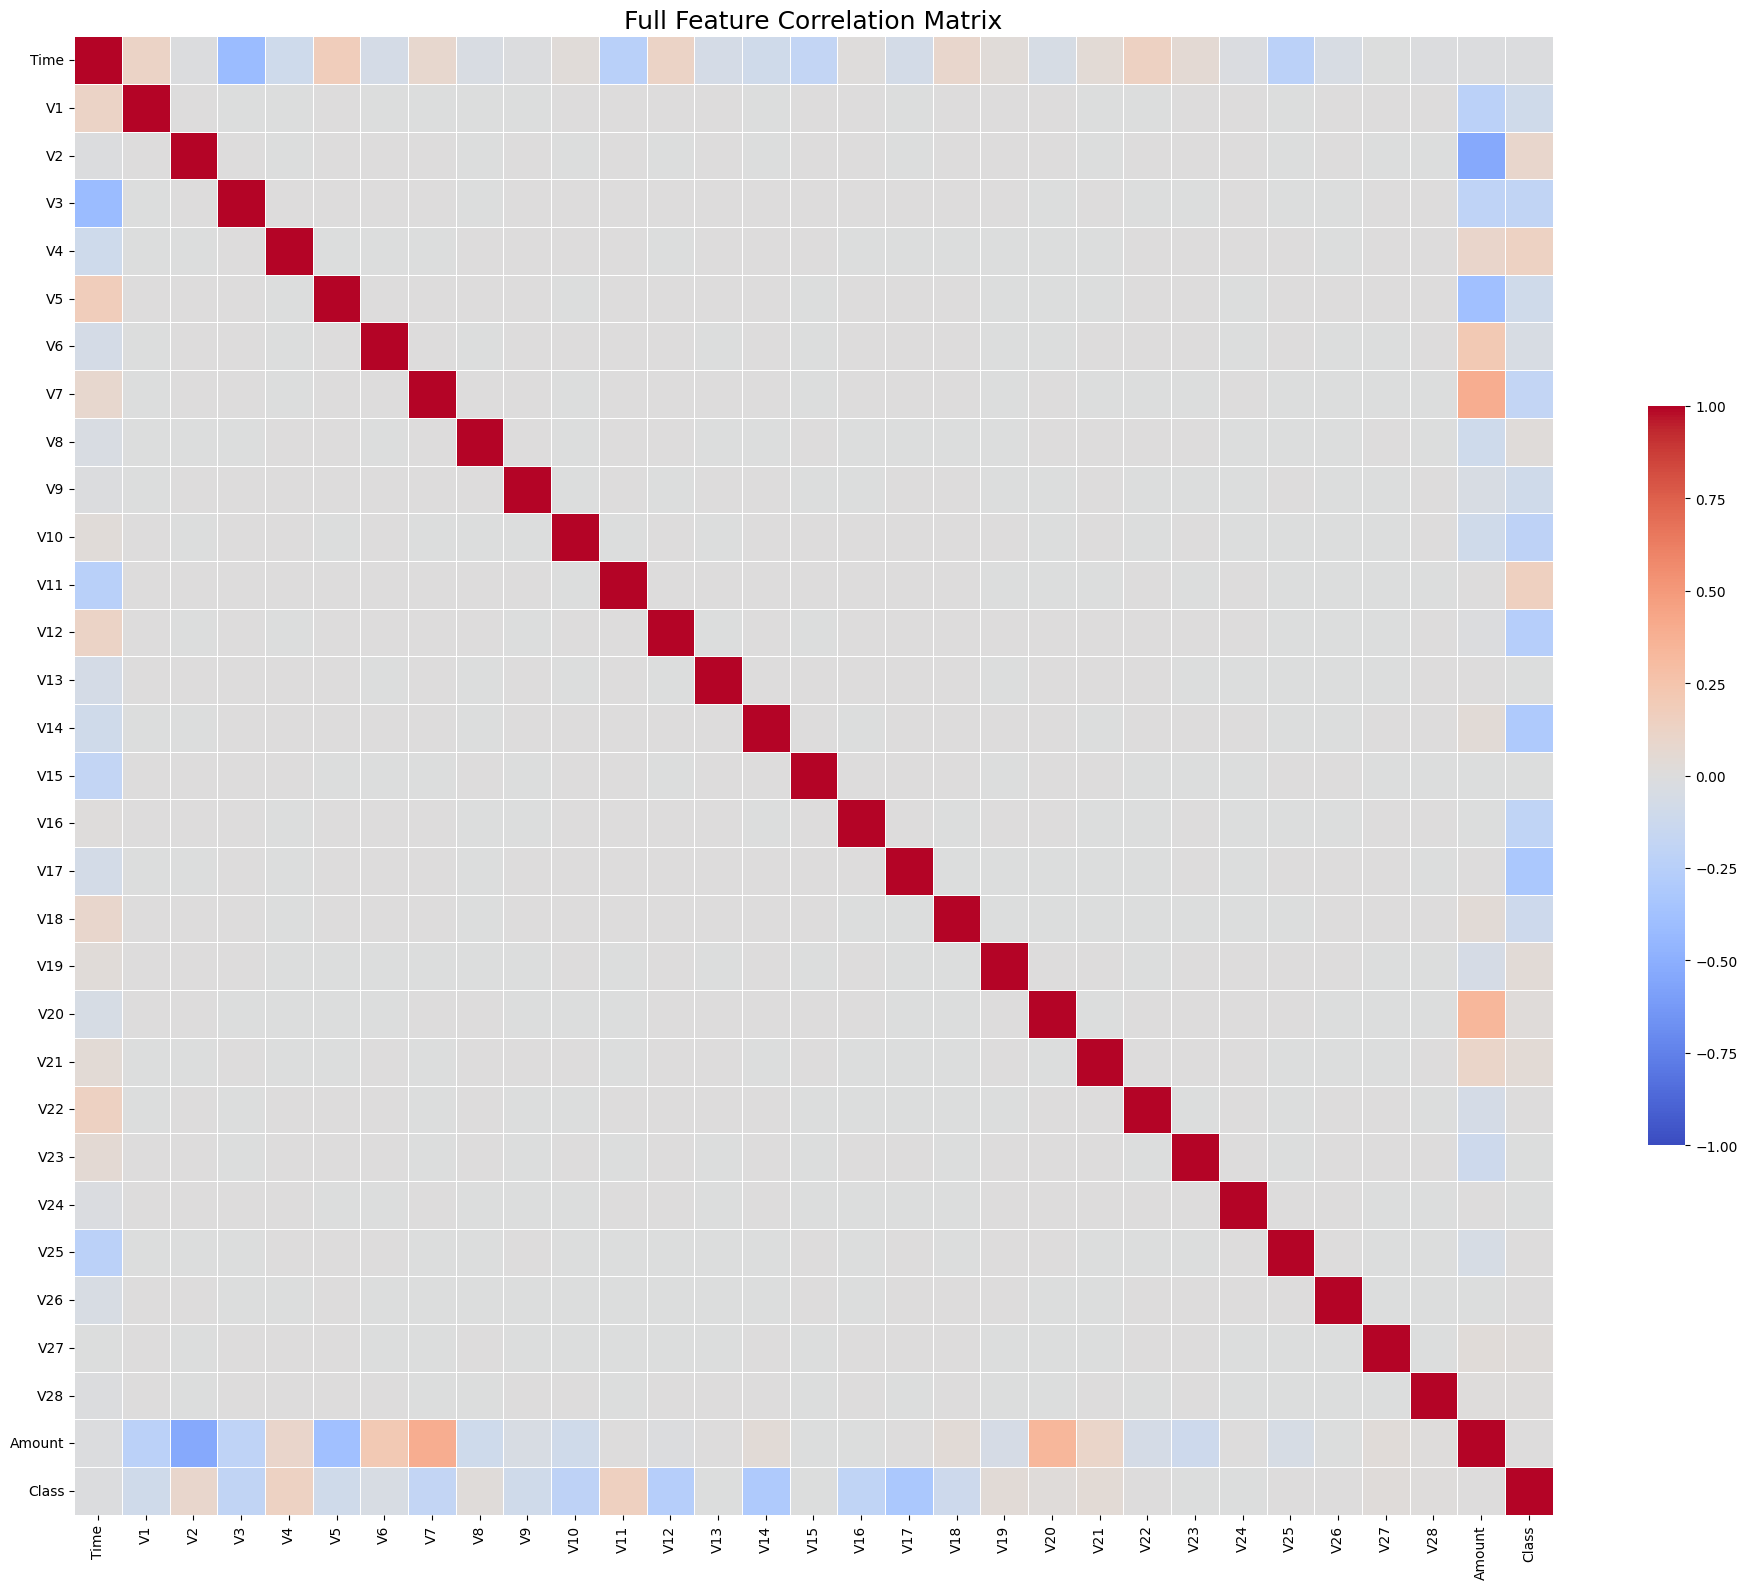

In [10]:
# Compute correlations with the Class column
correlations = df.corr()

plt.figure(figsize=(20,16))

sns.heatmap(correlations, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .5})


plt.title('Full Feature Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

### Class Vs Features 

In [11]:
import pandas as pd

# 1. Calculate the correlations specifically with the Class column
class_correlations = df.corr()['Class'].drop('Class')

# 2. Group 1: Positive Correlations (Orange/Red signals)
# Sorted descending: Strongest positive correlations at the top
orange_group = class_correlations[class_correlations > 0].sort_values(ascending=False)

# 3. Group 2: Negative Correlations (Blue signals)
# Sorted ascending: Deepest negative correlations (strongest signals) at the top
blue_group = class_correlations[class_correlations < 0].sort_values(ascending=True)

# --- Print the Results Cleanly ---
print("==================================================")
print("🍊 ORANGE GROUP: Positive Correlation with Fraud")
print("   (Higher feature values = Higher Fraud Risk)")
print("==================================================")
print(orange_group.to_frame(name='Correlation'))

print("\n" + "="*50)
print("🔹 BLUE GROUP: Negative Correlation with Fraud")
print("   (Lower/More Negative feature values = Higher Fraud Risk)")
print("==================================================")
print(blue_group.to_frame(name='Correlation'))

🍊 ORANGE GROUP: Positive Correlation with Fraud
   (Higher feature values = Higher Fraud Risk)
        Correlation
V11        0.154876
V4         0.133447
V2         0.091289
V21        0.040413
V19        0.034783
V20        0.020090
V8         0.019875
V27        0.017580
V28        0.009536
Amount     0.005632
V26        0.004455
V25        0.003308
V22        0.000805

🔹 BLUE GROUP: Negative Correlation with Fraud
   (Lower/More Negative feature values = Higher Fraud Risk)
      Correlation
V17     -0.326481
V14     -0.302544
V12     -0.260593
V10     -0.216883
V16     -0.196539
V3      -0.192961
V7      -0.187257
V18     -0.111485
V1      -0.101347
V9      -0.097733
V5      -0.094974
V6      -0.043643
Time    -0.012323
V24     -0.007221
V13     -0.004570
V15     -0.004223
V23     -0.002685


## 🛑 Feature Drop Strategy

### 📊 Key Insights from EDA
* **Feature Independence:** Because features $V1$ through $V28$ are the components of a PCA transformation, they exhibit **zero mutual correlation** (they are mutually orthogonal). 
* **Target Alignment:** While the features don't interact with one another, a distinct subset shows strong positive or negative linear relationships with the target variable (`Class`).

---

### 🗑️ Columns to Remove

| Feature | Correlation with Class | Justification for Dropping |
| :--- | :---: | :--- |
| **`Time`** | `-0.012323` | Extremely weak linear correlation. Real-world logic dictates that fraudulent transactions are dynamic and can occur at any hour of the day, making raw time an unreliable predictor. |

> 💡 **Note on All Other Features:** > * **`Amount`**: Although raw `Amount` has a low linear correlation (`0.005632`), its distribution is highly non-linear (fraud clusters strictly at lower amounts while normal data has extreme outliers). We will **keep** it for non-linear modeling splits.
> * **Low-Corr PCA Features**: We will **keep** the remaining low-correlation $V$ features (like `V22`, `V23`, etc.). While their linear signal is weak, advanced non-linear models can still leverage them to find complex fraud patterns.

In [12]:
df = df.drop('Time', axis=1)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Rescaling

In [13]:
from sklearn.preprocessing import RobustScaler
rob = RobustScaler()
df['Amount'] = rob.fit_transform(df[['Amount']])

df[:2]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0


## ⚖️ Handling Class Imbalance: Resampling Strategies

Because our dataset is heavily skewed (~492 fraud cases vs. ~284,000 normal cases), standard machine learning algorithms will suffer from severe bias. We can balance the classes using one of three primary strategies:

---

### 🔹 1. Random Undersampling
* **Mechanism:** Mathematically downsizes the majority class. It keeps all 492 fraud transactions and randomly selects exactly 492 normal transactions, discarding the rest.
* **Dataset Impact:** Shrinks the total dataset to a lean **984 rows**.
* **Pros:** Blazing fast execution; great for rapid baseline prototyping.
* **Cons:** **Massive information loss.** By throwing away 99.8% of legitimate transactions, the model misses out on the true variance of normal user behavior.

---

### 🍊 2. Synthetic Oversampling (SMOTE)
* **Mechanism:** Synthetic Minority Over-sampling Technique expands the minority class by drawing mathematical lines between real fraud cases and generating synthetic fraud points along those vectors.
* **Dataset Impact:** Inflates the total dataset to roughly **568,000 rows**.
* **Pros:** Zero information loss; retains every shred of real-world data from the legitimate class.
* **Cons:** Training times scale up drastically from seconds to minutes. Risk of over-generalizing if synthetic points cross into normal data boundaries.

---

### 🚀 3. Hybrid (Combination) Sampling & Cleaning
* **Mechanism:** A multi-step technique that blends both approaches to bypass their individual limitations. It dynamically handles class generation while pruning the noisy boundaries between classes.

#### 🛠️ Core Hybrid Implementation Methods:
* **SMOTE + Tomek Links:** First, SMOTE generates synthetic minority examples to balance the classes. Then, Tomek Links identifies pairs of instances from different classes that are extremely close to each other and removes the overlapping/noisy majority samples to create a perfectly clear decision boundary.
* **SMOTE + ENN (Edited Nearest Neighbors):** SMOTE initially oversamples the minority class, and then ENN is applied to the entire dataset to remove any instance whose class label differs from the majority of its $k$-nearest neighbors. This aggressively smooths out noise and clarifies cluster definition.
* **ODR-BSMOTE:** Combines Optimization-Driven Undersampling (ODR) to first eliminate redundant majority samples, then applies Boundary-SMOTE (BSMOTE) to synthesize new samples exclusively near the critical decision boundaries.

---

## 📊 Strategic Breakdown

| Metric | Random Undersampling | SMOTE (Oversampling) | Hybrid Sampling Methods |
| :--- | :--- | :--- | :--- |
| **Data Retention** | Loses 99.8% of Normal Class | Preserves 100% of Normal Data | Keeps a Diverse, Controlled Subset |
| **Training Speed** | ⚡ Blazing Fast (Seconds) | 🐢 Heavy Computation (Minutes) | 🏎️ Balanced & Efficient (Seconds) |
| **Risk Factor** | Underfitting normal patterns | Overfitting synthetic patterns | Requires careful pipeline tuning |
| **Best Used For** | Fast baselines & initial testing | Production-ready final models | High-performance boundary cleaning |

> 🚨 **Golden Rule of Resampling:** To prevent severe data leakage, **never** resample the entire dataset at once. We must perform our `train_test_split` first, and apply these techniques **only to the training set**. The test set must always remain raw and imbalanced to accurately reflect real-world performance.

In [14]:
%pip install imblearn
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek, SMOTEENN

# 1. Clean up features: Drop the duplicate 'Amount_scaled' and use the scaled 'Amount'
X = df.drop(columns=['Class', 'Amount_scaled'])
y = df['Class']

# 2. Split into Train and Test sets FIRST (Golden Rule to prevent Data Leakage!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original Training Distribution: {np.bincount(y_train)}")
print("-" * 50)

# ==========================================
# 🚀 CHOOSE YOUR HYBRID METHOD HERE
# ==========================================

# Option A: SMOTE + Tomek Links (Creates a clean, crisp boundary)
hybrid_sampler = SMOTETomek(random_state=42)

# Option B: SMOTE + ENN (Aggressively clears out boundary noise)
# To use this instead, uncomment the line below:
# hybrid_sampler = SMOTEENN(random_state=42)

# ==========================================

# 3. Fit the hybrid pipeline ONLY to the training data
X_train_hybrid, y_train_hybrid = hybrid_sampler.fit_resample(X_train, y_train)

print("📊 Final Hybrid Balanced Training Set")
print("-" * 50)
print(pd.Series(y_train_hybrid).value_counts())

Note: you may need to restart the kernel to use updated packages.


KeyError: "['Amount_scaled'] not found in axis"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the top skewed features we found during correlation analysis
# (We will pick a mix of top positive and negative drivers to inspect)
features_to_plot = ['V17', 'V14', 'V12', 'V11', 'V4', 'Amount']

# 2. Set up a clean grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# 3. Plot the distributions
for i, col in enumerate(features_to_plot):
    # Plot Original Imbalanced Training Data Distribution (Grey/Alpha)
    sns.kdeplot(data=X_train, x=col, ax=axes[i], color='gray', label='Original (Imbalanced)', fill=True, alpha=0.2)
    
    # Plot New Hybrid Balanced Training Data Distribution (Blue/Orange mix)
    sns.kdeplot(data=X_train_hybrid, x=col, ax=axes[i], color='darkorange', label='Hybrid Balanced (SMOTE+Tomek)', fill=False, linewidth=2)
    
    # Aesthetics
    axes[i].set_title(f'Distribution & Skewness of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize and train the Logistic Regression model
# We increase max_iter to ensure the model has plenty of steps to converge
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_hybrid, y_train_hybrid)

# 2. Predict on the UNTOUCHED, imbalanced test set
y_pred = log_reg.predict(X_test)

# 3. Print the comprehensive evaluation report
print("=========================================")
print("🎯 Logistic Regression Performance (On Real Test Data)")
print("=========================================\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# 4. Plot a clean Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Normal', 'Fraud'], 
                                        cmap='Oranges', ax=ax, values_format='d')
plt.title("Confusion Matrix: Logistic Regression Baseline", fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
# Run this if you want an easier alternative to XGBoost!
!brew install libomp
%pip install lightgbm

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Re-prepare the features and target variables
X = df.drop(columns=['Class', 'Amount_scaled'])
y = df['Class']

# 2. Re-split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Re-run your SMOTE + Tomek Links hybrid sampling
print("⏳ Regenerating balanced hybrid datasets...")
hybrid_sampler = SMOTETomek(random_state=42)
X_train_hybrid, y_train_hybrid = hybrid_sampler.fit_resample(X_train, y_train)

# 4. Initialize and fit LightGBM on your fresh hybrid data
print("🚀 Training LightGBM Classifier (with fixed libomp)...")
lgb_model = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train_hybrid, y_train_hybrid)

# 5. Predict and Evaluate
y_pred_lgb = lgb_model.predict(X_test)

print("\n=========================================")
print("🎯 LightGBM Classifier Performance")
print("=========================================\n")
print(classification_report(y_test, y_pred_lgb, target_names=['Normal', 'Fraud']))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgb, display_labels=['Normal', 'Fraud'], 
                                        cmap='Oranges', ax=ax, values_format='d')
plt.title("Confusion Matrix: LightGBM Baseline", fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create a pipeline that generates polynomial combinations, then fits Logistic Regression
# We use degree=2 (squares and interactions). Inclusion of bias=False prevents redundant columns.
# We stick to a stronger regularization (C=0.1) to prevent overfitting the synthetic data.
nonlinear_log_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(max_iter=1000, C=0.1, random_state=42)
)

# 2. Train the non-linear pipeline on your hybrid balanced data
print("⏳ Training Non-Linear Logistic Regression (this might take a few seconds)...")
nonlinear_log_reg.fit(X_train_hybrid, y_train_hybrid)

# 3. Predict on your untouched, imbalanced test set
y_pred_nonlinear = nonlinear_log_reg.predict(X_test)

# 4. Print the performance evaluation
print("\n=========================================")
print("🎯 Non-Linear Logistic Regression Performance")
print("=========================================\n")
print(classification_report(y_test, y_pred_nonlinear, target_names=['Normal', 'Fraud']))

# 5. Plot the updated Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nonlinear, display_labels=['Normal', 'Fraud'], 
                                        cmap='Oranges', ax=ax, values_format='d')
plt.title("Confusion Matrix: Non-Linear Logistic Regression", fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
!brew install libomp

## Notes

## Experiments